In [1]:
from pathlib import Path

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import json

In [2]:
img_path = Path("../../data/promotion/245_004.adj.tif")
image = Image.open(img_path)
image_np = np.array(image.convert("L"))
print(f"Loaded image with shape: {image_np.shape} and dtype: {image_np.dtype} as NumPy array")

Loaded image with shape: (1523, 13772) and dtype: uint8 as NumPy array


In [3]:
def load_labkit_json(json_path: Path):
    with open(json_path, "r") as f:
        data = json.load(f)

    # Image size
    xmin, ymin = data["interval"]["min"]
    xmax, ymax = data["interval"]["max"]

    width = xmax - xmin + 1
    height = ymax - ymin + 1

    label_img = np.zeros((height, width), dtype=np.int32)

    # Fill labels
    for i, (class_id_str, coords) in enumerate(data["labels"].items()):
        
        class_id = int(i)
        for x, y in coords:
            label_img[y, x] = class_id   # IMPORTANT: (row=y, col=x)

    return label_img, data

In [6]:
labels_path = img_path.parent / f"{img_path.name}.labeling"

# Usage
instance_map, meta = load_labkit_json(labels_path)

print(instance_map.shape)
print("Unique labels:", instance_map.max())

(1523, 13772)
Unique labels: 3043


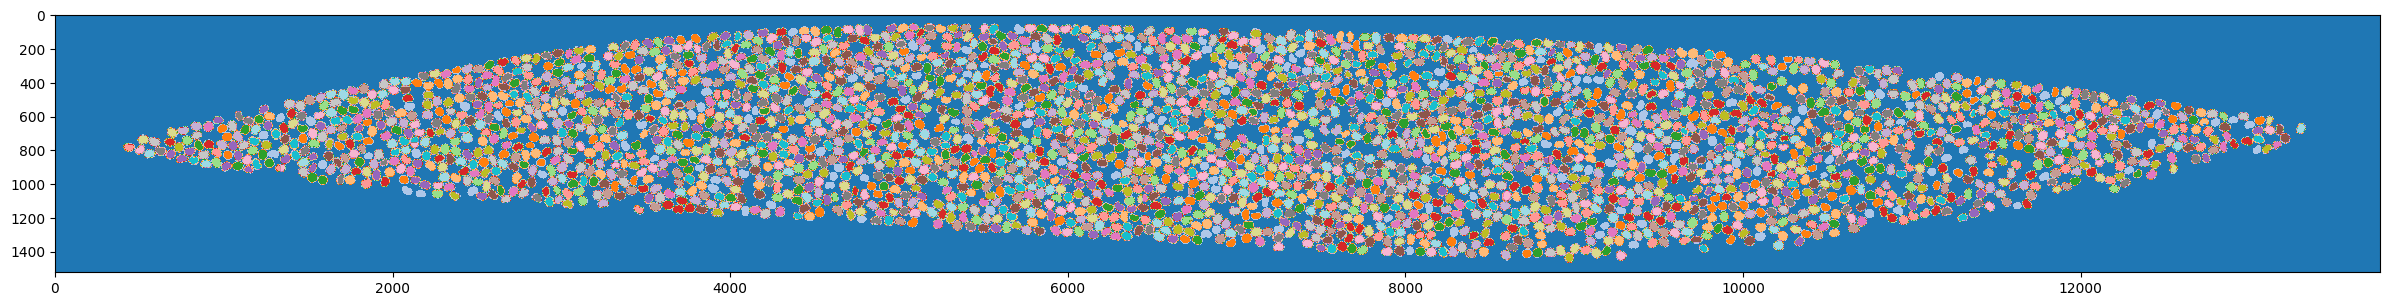

In [7]:
plt.figure(figsize=(30,10))

plt.imshow(instance_map, cmap="tab20")


In [8]:
from skimage.measure import regionprops
sorted_masks = []

for region in regionprops(instance_map):
    minr, minc, maxr, maxc = region.bbox  # (ymin, xmin, ymax, xmax)

    xmin = int(minc)
    ymin = int(minr)
    w = int(maxc - minc)
    h = int(maxr - minr)

    cropped_mask = (instance_map[minr:maxr, minc:maxc] == region.label)

    seg = {
        "id": int(region.label),
        "area": int(region.area),
        "diameter": float(region.equivalent_diameter),
        "bbox": (xmin, ymin, w, h),  # <- now in requested format
        "centroid": tuple(region.centroid),
        "segmentation_crop": cropped_mask.astype(np.uint8)
    }

    sorted_masks.append(seg)


sorted_masks = sorted(sorted_masks, key=lambda m: m["diameter"], reverse=True)


spacing = 0.11688678457992144

diameters = [obj["diameter"] for obj in sorted_masks]
avg_diameter = np.mean(diameters)*spacing
print(f"Average diameter in microns: {avg_diameter:.2f} µm")



Average diameter in microns: 6.58 µm


In [9]:
from sam2.addons import show_anns

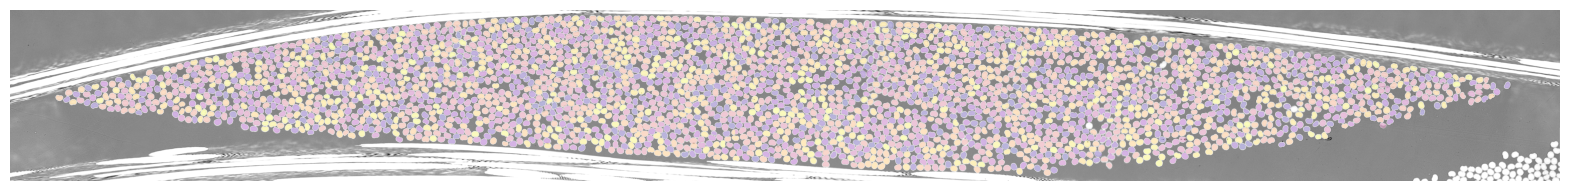

In [24]:
# Display segmented masks on top of the image
plt.figure(figsize=(20, 5))
plt.imshow(image_np, cmap="gray")

# Random-color instance masks using the "plasma" colormap
label_canvas = show_anns(
    sorted_masks,
    canvas_shape=image_np.shape,
    alpha=0.3,
    borders =False,          # overlay transparency (0=transparent, 1=opaque)
    cmap_key="plasma"   # Matplotlib colormap for mask colors
)

plt.axis('off')
plt.show()

In [25]:
def to_uint8(x: np.ndarray) -> np.ndarray:
    """Convert float/bool/int arrays to uint8 safely."""
    if x.dtype == np.uint8:
        return x
    if x.dtype == np.bool_:
        return (x.astype(np.uint8) * 255)

    x = x.astype(np.float32)
    # If it's likely already in [0,1], scale up; else normalize
    if x.max() <= 1.0 and x.min() >= 0.0:
        x = x * 255.0
    else:
        mx = x.max()
        mn = x.min()
        if mx > mn:
            x = (x - mn) * (255.0 / (mx - mn))
        else:
            x = np.zeros_like(x)
    return np.clip(x, 0, 255).astype(np.uint8)

# --- 1) Make RGB image from grayscale image_np ---
img_u8 = to_uint8(image_np)

# ensure grayscale 2D
if img_u8.ndim != 2:
    raise ValueError(f"Expected image_np as (H,W) grayscale, got {img_u8.shape}")

img_pil = Image.fromarray(img_u8, mode="L").convert("RGB")

# --- 2) Make RGBA overlay from label_canvas ---
# label_canvas expected shape (H,W,4)
if label_canvas.ndim != 3 or label_canvas.shape[-1] != 4:
    raise ValueError(f"Expected label_canvas as (H,W,4) RGBA, got {label_canvas.shape}")

rgba_u8 = to_uint8(label_canvas)
rgba_pil = Image.fromarray(rgba_u8, mode="RGBA")

# --- 3) Half resolution ---
w, h = img_pil.size
half_size = (max(1, w // 2), max(1, h // 2))

# For downsampling, BOX is a good averaging filter (often best for microscopy)
img_half  = img_pil.resize(half_size, resample=Image.Resampling.BOX)
rgba_half = rgba_pil.resize(half_size, resample=Image.Resampling.BOX)

# --- 4) Save ---
stem = Path(img_path).stem  # img_path can be str or Path
img_half.save(f"{stem}.image_half.png",dpi=(72,72))
rgba_half.save(f"{stem}.masks_half.png",dpi=(72,72))

In [26]:
def to_uint8(x: np.ndarray) -> np.ndarray:
    """Convert float/bool/int arrays to uint8 safely."""
    if x.dtype == np.uint8:
        return x
    if x.dtype == np.bool_:
        return (x.astype(np.uint8) * 255)

    x = x.astype(np.float32)
    if x.max() <= 1.0 and x.min() >= 0.0:
        x = x * 255.0
    else:
        mx, mn = x.max(), x.min()
        if mx > mn:
            x = (x - mn) * (255.0 / (mx - mn))
        else:
            x = np.zeros_like(x)
    return np.clip(x, 0, 255).astype(np.uint8)

# --- 1) Base RGB from grayscale image_np ---
img_u8 = to_uint8(image_np)
if img_u8.ndim != 2:
    raise ValueError(f"Expected image_np as (H,W) grayscale, got {img_u8.shape}")

base_rgb = Image.fromarray(img_u8, mode="L").convert("RGB")

# --- 2) Overlay RGBA from label_canvas ---
if label_canvas.ndim != 3 or label_canvas.shape[-1] != 4:
    raise ValueError(f"Expected label_canvas as (H,W,4) RGBA, got {label_canvas.shape}")

overlay_rgba = Image.fromarray(to_uint8(label_canvas), mode="RGBA")

# --- 3) Half resolution (same filter for both) ---
w, h = base_rgb.size
half_size = (max(1, w // 2), max(1, h // 2))

base_half = base_rgb.resize(half_size, resample=Image.Resampling.BOX).convert("RGBA")
ovr_half  = overlay_rgba.resize(half_size, resample=Image.Resampling.BOX)

# --- 4) Composite and save ---
comp_half = Image.alpha_composite(base_half, ovr_half).convert("RGB")

stem = Path(img_path).stem
comp_half.save(f"{stem}.composite_half.png", dpi=(72, 72))

In [13]:
width, height = img_pil.size

# spacing in micrometers per pixel
spacing_um = spacing  

# convert to mm per pixel
spacing_mm = spacing_um / 1000.0

image_width_mm  = width  * spacing_mm
image_height_mm = height * spacing_mm

rel_1mm_x = 1. / image_width_mm
rel_1mm_y = 1. / image_height_mm

print(f"Image size: {image_width_mm:.3f} mm x {image_height_mm:.3f} mm")
print(f"1 mm relative to width  = {rel_1mm_x:.6f}")
print(f"1 mm relative to height = {rel_1mm_y:.6f}")

Image size: 1.610 mm x 0.178 mm
1 mm relative to width  = 0.621209
1 mm relative to height = 5.617391


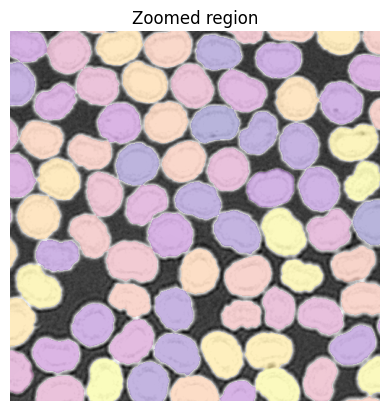

In [14]:
y0, x0 = 500,3000
size = 512

image_np_cropped = image_np[y0:y0+size, x0:x0+size]
label_canvas_cropped = label_canvas[y0:y0+size, x0:x0+size,:]

plt.imshow(image_np_cropped, cmap="gray")
plt.imshow(label_canvas_cropped)
plt.axis("off")
plt.title("Zoomed region")
plt.show()

In [15]:
# --- 1) Make RGB image from grayscale image_np ---
img_u8 = to_uint8(image_np_cropped)

# ensure grayscale 2D
if img_u8.ndim != 2:
    raise ValueError(f"Expected image_np as (H,W) grayscale, got {img_u8.shape}")

img_pil = Image.fromarray(img_u8, mode="L").convert("RGB")

# --- 2) Make RGBA overlay from label_canvas ---
# label_canvas expected shape (H,W,4)
if label_canvas_cropped.ndim != 3 or label_canvas_cropped.shape[-1] != 4:
    raise ValueError(f"Expected label_canvas as (H,W,4) RGBA, got {label_canvas_cropped.shape}")

rgba_u8 = to_uint8(label_canvas_cropped)
rgba_pil = Image.fromarray(rgba_u8, mode="RGBA")

stem = Path(img_path).stem 
img_pil.save(f"{stem}_{y0}_{x0}.image.png")
rgba_pil.save(f"{stem}_{y0}_{x0}.labels.png")



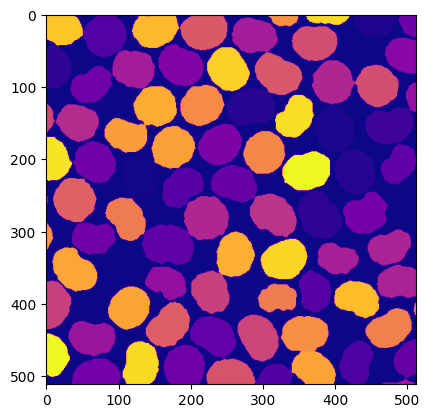

In [16]:
labels_map = instance_map[y0:y0+size, x0:x0+size]
plt.imshow(labels_map, cmap="plasma")

In [20]:
from sam2.addons import s2_descriptor
import torch


# Convert the instance label map to a binary phase map
# (1 = foreground/fibers, 0 = background)
binary_map_tensor = torch.tensor((labels_map > 0), dtype=torch.long).unsqueeze(0)

# Compute the full 2D S2 descriptor and its radial average
S2, S2r = s2_descriptor(binary_map_tensor, radial=True)

# Convert tensors to NumPy arrays for plotting or further processing
binary_np = binary_map_tensor.squeeze(0).cpu().numpy()
s2_np     = S2.squeeze(0).cpu().numpy()
s2r_np    = S2r.squeeze().cpu().numpy()

s2_np = s2_np/s2_np.max()  # Radial S2 as a function of radius r

In [21]:
# --- 1) Center crop to 512x512 ---
def center_crop(arr,size = 512):
    h, w = arr.shape[-2], arr.shape[-1]
    cy, cx = h // 2, w // 2
    half = size // 2
    return arr[..., cy-half:cy+half, cx-half:cx+half]

s2_np = S2.squeeze(0).cpu().numpy()
s2_crop = center_crop(s2_np)

# --- 2) Normalize safely to [0,1] ---
s2_min = s2_crop.min()
s2_max = s2_crop.max()

if s2_max > s2_min:
    s2_norm = (s2_crop - s2_min) / (s2_max - s2_min)
else:
    s2_norm = np.zeros_like(s2_crop)

# --- 3) Apply plasma colormap ---
cmap = plt.get_cmap("plasma")
rgba = cmap(s2_norm)  # returns float RGBA in [0,1]

# Convert to uint8
rgba_uint8 = (rgba * 255).astype(np.uint8)

# --- 4) Save ---
Image.fromarray(rgba_uint8, mode="RGBA").save(f"{stem}_{y0}_{x0}-{size}.s2.png")

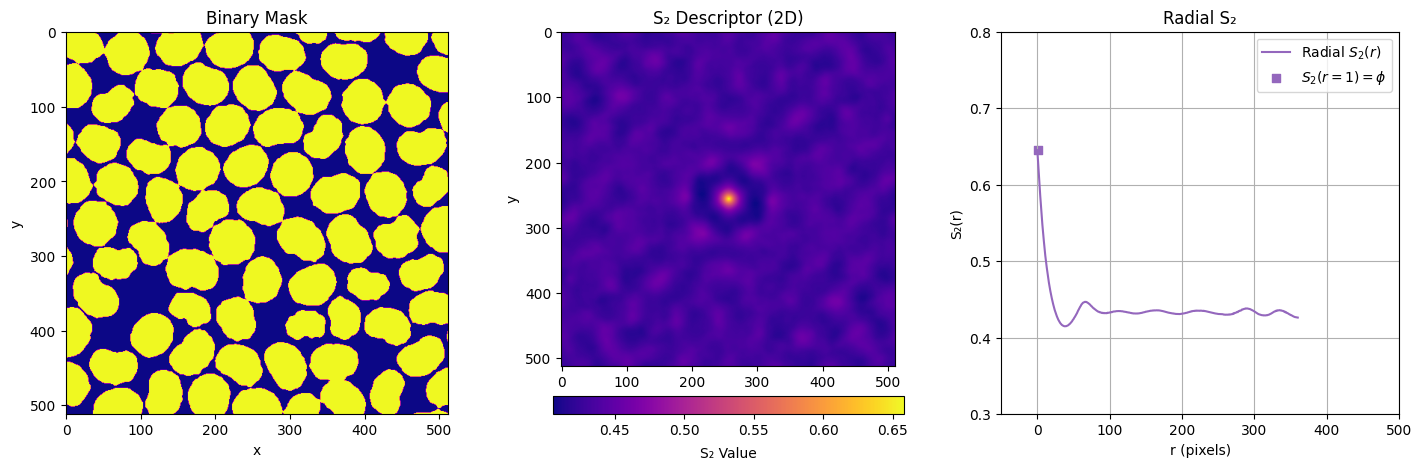

In [121]:
# Plot
fig, axs = plt.subplots(1, 3, figsize=(14.4, 4.8))

# --- Binary map ---
axs[0].imshow(binary_np, cmap="plasma")
axs[0].set_title("Binary Mask")
axs[0].set_xlabel(r"x")
axs[0].set_ylabel(r"y")

# --- S2 2D map ---
im1 = axs[1].imshow(s2_np, cmap="plasma")
axs[1].set_title("S₂ Descriptor (2D)")
axs[1].set_xlabel(r"x")
axs[1].set_ylabel(r"y")
# horizontal colorbar below the image
cbar1 = fig.colorbar(
    im1,
    ax=axs[1],
    orientation="horizontal",
    fraction=0.046,   # size of the bar relative to the axis
    pad=0.08          # spacing between image and colorbar
)
cbar1.set_label("S₂ Value", labelpad=6)

# --- Radial S2 ---
axs[2].plot(s2r_np[1:], color="tab:purple", label="Radial $S_2(r)$")
axs[2].scatter(1, s2r_np[1], marker="s", color="tab:purple", label=r"$S_2(r=1)=\phi$")

axs[2].set_xlim(-50, 500)
axs[2].set_ylim(0.3, 0.8)
axs[2].set_title("Radial S₂")
axs[2].set_xlabel("r (pixels)")
axs[2].set_ylabel("S₂(r)")
axs[2].grid(True)
axs[2].legend(loc="best")

plt.tight_layout()
plt.show()

In [19]:
from sam2.addons import (
    s2_descriptor,
    phi_descriptor,
    corr_length_halfheight,
    integral_range_from_S2r,
    rve_size_from_integral_range,
)

# --- 1) Binary phase map (1 = fibers, 0 = background) ---
binary_map_tensor = torch.tensor(labels_map > 0, dtype=torch.long).unsqueeze(0)

# --- 2) Statistical descriptors: S2, S2(r), volume fraction, correlation length ---
s2, s2r = s2_descriptor(binary_map_tensor, radial=True)
phi     = phi_descriptor(binary_map_tensor)
corrlen = corr_length_halfheight(s2r, phi)

# Convert to NumPy for plotting or external analysis
binary_np = binary_map_tensor.squeeze(0).cpu().numpy()
s2_np     = s2.squeeze(0).cpu().numpy()
s2r_np    = s2r.squeeze().cpu().numpy()

# --- 3) Integral range A_int (in px²) ---
A_int = integral_range_from_S2r(s2r, phi)

# --- 4) Target coefficient of variation (COV) ---
cv_target = 0.05  # e.g. 5% scatter (use 0.10 for 10%)

# --- 5) RVE side length in pixels ---
L_rve_px = rve_size_from_integral_range(phi, A_int, cv_target)

# --- 6) Print summary ---
print(f"phi_mean           = {phi.item():.4f}")
print(f"correlation length = {corrlen.item():.4f} px")
print(f"A_int_mean         = {A_int.item():.2f} px²")
print(f"Target COV         = {cv_target:.3f}")
print(f"RVE side           = {L_rve_px.item():.1f} px")

phi_mean           = 0.6583
correlation length = 9.0000 px
A_int_mean         = 475.07 px²
Target COV         = 0.050
RVE side           = 206.7 px
